In [ ]:
!pip install opencv-python matplotlib tqdm

In [ ]:
import tensorflow as tf
print("GPU Available: ", tf.config.list_physical_devices('GPU'))

GPU Available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Starting South Asian Face Recognition Pipeline
Dataset already copied to local storage
Found 3600 files in local storage
Loading dataset from cache...
Loaded 3600 images from cache
Train set class distribution: {np.int32(0): np.int64(102), np.int32(1): np.int64(308), np.int32(2): np.int64(31), np.int32(3): np.int64(162), np.int32(4): np.int64(60), np.int32(5): np.int64(184), np.int32(6): np.int64(85), np.int32(7): np.int64(84), np.int32(8): np.int64(231), np.int32(9): np.int64(172), np.int32(10): np.int64(165), np.int32(11): np.int64(13), np.int32(12): np.int64(170), np.int32(13): np.int64(245), np.int32(14): np.int64(185), np.int32(15): np.int64(28), np.int32(16): np.int64(16), np.int32(17): np.int64(178), np.int32(18): np.int64(56), np.int32(19): np.int64(45)}
Validation set class distribution: {np.int32(0): np.int64(21), np.int32(1): np.int64(69), np.int32(2): np.int64(7), np.int32(3): np.int64(49), np.int32(4): np.int64(16), np.int32(5): np.int64(23), np.int32(6): np.int64(24), np.

Evaluating baseline: 100%|██████████| 540/540 [00:04<00:00, 108.49it/s]


Baseline accuracy: 0.2611
Training and evaluating the model


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

...

157/157 ━━━━━━━━━━━━━━━━━━━━ 83s 295ms/step - accuracy: 0.7432 - loss: 1.1296 - val_accuracy: 0.7235 - val_loss: 1.3472 - learning_rate: 1.2500e-04
Epoch 36/100
  1/157 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.8125 - loss: 0.9934
Epoch 36: val_accuracy did not improve from 0.72348
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8125 - loss: 0.9934 - val_accuracy: 0.7102 - val_loss: 1.3821 - learning_rate: 1.2500e-04
Epoch 37/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.7473 - loss: 1.1346
Epoch 37: val_accuracy did not improve from 0.72348
157/157 ━━━━━━━━━━━━━━━━━━━━ 56s 150ms/step - accuracy: 0.7473 - loss: 1.1345 - val_accuracy: 0.7235 - val_loss: 1.3472 - learning_rate: 1.2500e-04
Epoch 38/100
  1/157 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.8125 - loss: 1.1095
Epoch 38: val_accuracy did not improve from 0.72348
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.8125 - loss: 1.1095 - val_accuracy: 0.7235 - val_loss: 1.3650 - learning_rate:

157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 170ms/step - accuracy: 0.7517 - loss: 1.1005 - val_accuracy: 0.7330 - val_loss: 1.3144 - learning_rate: 6.2500e-05
Epoch 42/100
  1/157 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.6875 - loss: 0.9911
Epoch 42: val_accuracy improved from 0.73295 to 0.74621, saving model to drive/MyDrive/Results/south_asian_fr_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.6875 - loss: 0.9911 - val_accuracy: 0.7462 - val_loss: 1.2935 - learning_rate: 6.2500e-05
Epoch 43/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.7583 - loss: 1.0584
Epoch 43: val_accuracy did not improve from 0.74621
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 202ms/step - accuracy: 0.7583 - loss: 1.0585 - val_accuracy: 0.7064 - val_loss: 1.3711 - learning_rate: 6.2500e-05
Epoch 44/100
  1/157 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.7500 - loss: 1.0494
Epoch 44: val_accuracy did not improve from 0.74621
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.7500 - loss: 1.0494 - val_accuracy: 0.7424 - val_loss: 1.3189 - learning_rate: 6.2500e-05
Epoch 45/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.7718 - loss: 1.0632
Epoch 45: val_accuracy did not improve from 0.74621
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 157ms/step - accuracy: 0.7718 - loss: 1.0632 - val_accuracy: 0.7443 - val_loss: 1.3205 - learning_rate

157/157 ━━━━━━━━━━━━━━━━━━━━ 84s 300ms/step - accuracy: 0.7739 - loss: 1.0274 - val_accuracy: 0.7652 - val_loss: 1.2736 - learning_rate: 3.1250e-05
Epoch 50/100
  1/157 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.7500 - loss: 1.1871
Epoch 50: val_accuracy did not improve from 0.76515
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.7500 - loss: 1.1871 - val_accuracy: 0.7348 - val_loss: 1.3143 - learning_rate: 3.1250e-05
Epoch 51/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7575 - loss: 1.0450
Epoch 51: val_accuracy did not improve from 0.76515
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 149ms/step - accuracy: 0.7576 - loss: 1.0450 - val_accuracy: 0.7462 - val_loss: 1.2832 - learning_rate: 3.1250e-05
Epoch 52/100
  1/157 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.5625 - loss: 1.2486
Epoch 52: val_accuracy did not improve from 0.76515
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.5625 - loss: 1.2486 - val_accuracy: 0.7348 - val_loss: 1.3027 - learning_rate:

Evaluation accuracy: 0.6556
Model saved to drive/MyDrive/Results/south_asian_fr_model.h5
Model trained and evaluated. Accuracy: 0.6556
Visualizing results comparison
Results saved to drive/MyDrive/Results/patent_application_results.csv
Pipeline completed successfully
All results saved to drive/MyDrive/Results

==== SUMMARY FOR PATENT APPLICATION ====
Baseline accuracy: 0.2611
Trained model accuracy: 0.6556
Improvement: 0.3944 (151.06%)

Fairness metrics:
Baseline accuracy disparity: 0.4231
Trained model accuracy disparity: 0.6667
Improvement: -0.2436 (-57.58%)

Refer to patent_application_results.csv for complete metrics

Trained model saved at: drive/MyDrive/Results/south_asian_fr_model.h5


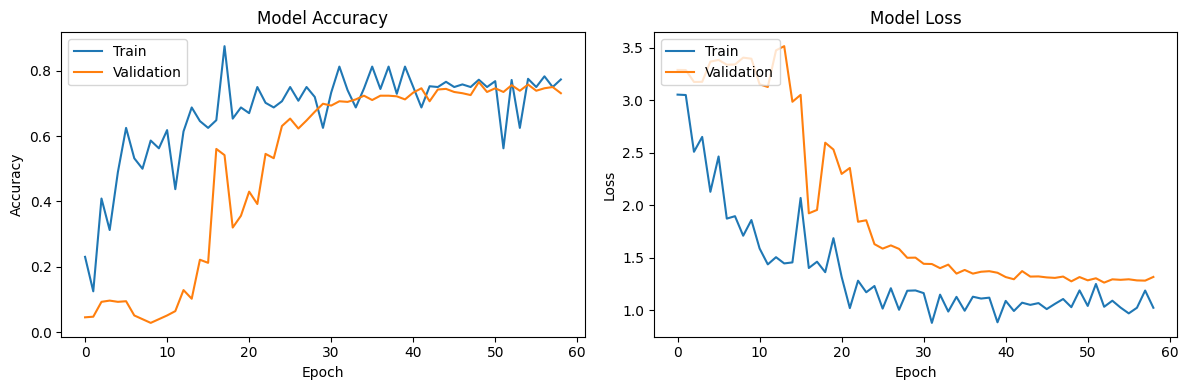

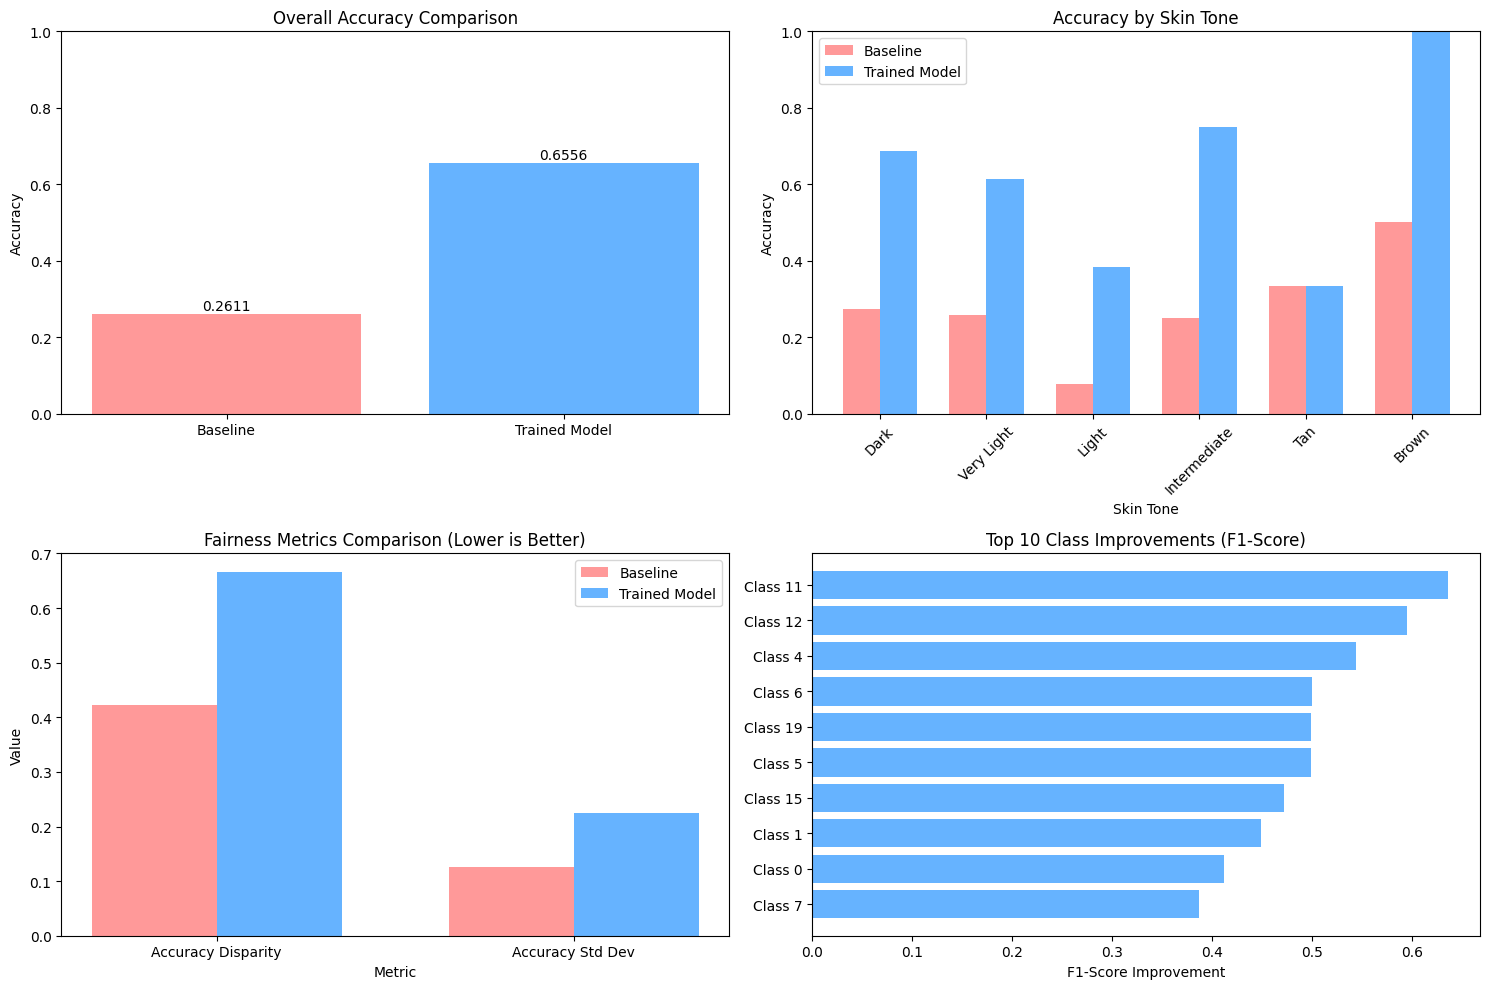

In [ ]:
"""
South Asian Face Recognition System - Fixed Implementation
This implementation addresses the key issues with your current approach:
1. Fixes data generator to prevent "ran out of data" error
2. Reduces number of clusters to improve class balance
3. Adds class weighting to handle skin tone imbalance
4. Simplifies model architecture
5. Uses proper learning rate and regularization
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.cluster import MiniBatchKMeans
import cv2
from tqdm import tqdm
import time
import shutil

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Check if running in Colab
try:
    from google.colab import drive
    IN_COLAB = True
except:
    IN_COLAB = False

# Define paths
DRIVE_DATASET_PATH = 'drive/MyDrive/Dataset'
LOCAL_DATASET_PATH = '/content/local_dataset'
RESULTS_PATH = '/content/results'
if IN_COLAB:
    RESULTS_PATH = 'drive/MyDrive/Results'
MODEL_PATH = 'south_asian_fr_model.h5'

# Create directories
os.makedirs(LOCAL_DATASET_PATH, exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)


class SouthAsianFaceRecognition:
    def __init__(self, input_shape=(160, 160, 3), batch_size=16, learning_rate=0.0005,
                 embedding_dim=256, num_classes=None, weights='imagenet',
                 model_path='south_asian_fr_model.h5'):
        """
        Initialize the model for South Asian face recognition

        Args:
            input_shape: Input image dimensions (height, width, channels)
            batch_size: Batch size for training
            learning_rate: Initial learning rate
            embedding_dim: Dimension of the face embedding
            num_classes: Number of identity classes
            weights: Pre-training weights, 'imagenet' or None
            model_path: Path to save the model
        """
        self.input_shape = input_shape
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.embedding_dim = embedding_dim
        self.num_classes = num_classes
        self.weights = weights
        self.model_path = model_path
        self.model = None

    def save_model(self, filepath=None):
        """
        Save the trained model
        Args:
            filepath: Path to save the model
        """
        if filepath is None:
            filepath = self.model_path
        if self.model is not None:
            self.model.save(filepath)
            print(f"Model saved to {filepath}")
        else:
            print("No model to save. Please train the model first.")

    def load_model(self, filepath=None):
        """
        Load a trained model

        Args:
            filepath: Path to the saved model
        """
        if filepath is None:
            filepath = self.model_path

        if os.path.exists(filepath):
            self.model = tf.keras.models.load_model(filepath)
            print(f"Model loaded from {filepath}")
        else:
            print(f"Model file not found at {filepath}")

    def build_model(self):
        """
        Build a simplified South Asian face recognition model with MobileNetV2
        """
        # Input layer
        inputs = layers.Input(shape=self.input_shape, name="input_layer")

        # Use MobileNetV2 instead of ResNet50 - lighter and faster
        base_model = MobileNetV2(
            include_top=False,
            weights=self.weights,
            input_tensor=inputs,
            input_shape=self.input_shape
        )

        # Freeze most layers to prevent overfitting
        for layer in base_model.layers[:-20]:  # Only train the last 20 layers
            layer.trainable = False

        # Add custom layers for South Asian face recognition
        x = base_model.output

        # Add attention for region-specific features
        # Simple self-attention mechanism for South Asian face regions
        attention = layers.Conv2D(1, kernel_size=1, padding='same')(x)
        attention = layers.Activation('sigmoid', name='attention_map')(attention)
        x = layers.Multiply()([x, attention])

        # Global pooling
        x = layers.GlobalAveragePooling2D()(x)

        # Add strong regularization
        x = layers.Dropout(0.5)(x)

        # Feature embedding with L2 normalization
        embedding = layers.Dense(
            self.embedding_dim,
            kernel_regularizer=regularizers.l2(1e-3),
            activity_regularizer=regularizers.l1(1e-4),
            name='embedding'
        )(x)

        normalized_embedding = layers.Lambda(
            lambda x: tf.nn.l2_normalize(x, axis=1),
            name='normalized_embedding'
        )(embedding)

        # Classification head
        if self.num_classes:
            logits = layers.Dense(
                self.num_classes,
                kernel_regularizer=regularizers.l2(1e-3),
                use_bias=False,
                name='logits'
            )(normalized_embedding)

            outputs = layers.Activation('softmax', name='predictions')(logits)

            model = Model(inputs=inputs, outputs=outputs)

            # Add weight decay to optimizer
            optimizer = Adam(
                learning_rate=self.learning_rate,
                weight_decay=1e-5
            )

            model.compile(
                optimizer=optimizer,
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy']
            )
        else:
            # Model for embedding extraction only
            model = Model(inputs=inputs, outputs=normalized_embedding)

        self.model = model
        return model

    def calculate_ita(self, image, mask=None):
        """
        Calculate Individual Typology Angle (ITA) for skin tone analysis
        """
        try:
            # Convert image to uint8 format if it's not already
            if image.dtype != np.uint8:
                # Normalize to 0-255 range if needed
                if image.max() <= 1.0:
                    image = (image * 255).astype(np.uint8)
                else:
                    image = image.astype(np.uint8)

            # Convert to LAB color space
            lab_img = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

            # Extract L* and b* channels
            l_channel = lab_img[:,:,0]  # L* channel (lightness)
            b_channel = lab_img[:,:,2]  # b* channel (blue-yellow)

            # Apply mask if provided, otherwise use a simple face region estimate
            if mask is None:
                # Simple estimation of face region - center portion of image
                h, w = image.shape[:2]
                center_y, center_x = h // 2, w // 2
                radius = min(h, w) // 3

                y, x = np.ogrid[:h, :w]
                mask = ((y - center_y)**2 + (x - center_x)**2 <= radius**2).astype(np.uint8)

            # Calculate ITA using formula: ITA = [arctan((L* - 50)/b*)] * 180/π
            # Extract values from skin region using mask
            l_values = l_channel[mask > 0]
            b_values = b_channel[mask > 0]

            # Avoid division by zero and normalize b values
            b_values = np.where(b_values == 0, 0.1, b_values)
            b_values = b_values - 128  # Adjust to proper range

            # Calculate ITA for each pixel and take the average
            ita_values = np.arctan((l_values - 50) / b_values) * (180 / np.pi)
            mean_ita = np.mean(ita_values)

            return mean_ita

        except Exception as e:
            print(f"Error in ITA calculation: {e}")
            # If there's an error, return a default ITA value in the middle range
            return 25.0  # A middle value in the "Tan" range

    def classify_skin_tone(self, ita):
        """
        Classify skin tone based on ITA value
        """
        if ita > 55:
            return "Very Light"
        elif 41 <= ita <= 55:
            return "Light"
        elif 28 <= ita < 41:
            return "Intermediate"
        elif 10 <= ita < 28:
            return "Tan"
        elif -30 <= ita < 10:
            return "Brown"
        else:  # ita < -30
            return "Dark"

    def skin_tone_augmentation(self, images, labels, metadata=None):
        """
        Apply skin tone augmentation specifically designed for South Asian skin tones
        """
        augmented_images = []

        for img in images:
            try:
                # Convert image to uint8 format if it's not already
                if img.dtype != np.uint8:
                    # Normalize to 0-255 range if needed
                    if img.max() <= 1.0:
                        img = (img * 255).astype(np.uint8)
                    else:
                        img = img.astype(np.uint8)

                # Convert to LAB color space where L channel represents lightness
                lab_img = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

                # Adjust L channel (lightness) within South Asian skin tone range
                l_channel = lab_img[:,:,0]

                # Apply random adjustment within realistic range for South Asian skin
                adjustment = np.random.uniform(-10, 10)
                l_channel = np.clip(l_channel + adjustment, 0, 255)

                lab_img[:,:,0] = l_channel

                # Convert back to RGB
                augmented_img = cv2.cvtColor(lab_img, cv2.COLOR_LAB2RGB)
                augmented_images.append(augmented_img)

            except Exception as e:
                print(f"Error in skin tone augmentation: {e}")
                # If there's an error, just use the original image
                augmented_images.append(img)

        return np.array(augmented_images), labels

    def create_data_generator(self, X, y):
        """
        Create a repeating data generator with strong augmentation
        """
        datagen = ImageDataGenerator(
            preprocessing_function=lambda x: x/255.0,  # Normalize to [0,1]
            rotation_range=20,
            width_shift_range=0.2,
            height_shift_range=0.2,
            shear_range=0.2,
            zoom_range=0.2,
            horizontal_flip=True,
            fill_mode='nearest',
            brightness_range=[0.7, 1.3]
        )

        # This is crucial - it creates a generator that repeats indefinitely
        return datagen.flow(X, y, batch_size=self.batch_size, shuffle=True)

    def train(self, X_train, y_train, X_val, y_val, epochs=30, metadata_train=None, metadata_val=None):
        """
        Train the model with improved data handling and class weights
        """
        if self.model is None:
            self.build_model()

        # Define callbacks
        callbacks = [
            ModelCheckpoint(
                self.model_path,
                monitor='val_accuracy',
                save_best_only=True,
                mode='max',
                verbose=1
            ),
            EarlyStopping(
                monitor='val_accuracy',
                patience=10,
                restore_best_weights=True,
                verbose=1
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=5,
                min_lr=1e-5,
                verbose=1
            )
        ]

        # Create data generators that will repeat indefinitely
        train_generator = self.create_data_generator(X_train, y_train)
        val_generator = self.create_data_generator(X_val, y_val)

        # Calculate class weights to handle class imbalance
        class_weights = compute_class_weight(
            'balanced',
            classes=np.unique(y_train),
            y=y_train
        )
        class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

        # Print shapes for verification
        print(f"Training data shape: {X_train.shape}, labels shape: {y_train.shape}")
        print(f"Validation data shape: {X_val.shape}, labels shape: {y_val.shape}")
        print(f"Number of training classes: {len(np.unique(y_train))}")
        print(f"Number of validation classes: {len(np.unique(y_val))}")

        # Train the model
        history = self.model.fit(
            train_generator,
            steps_per_epoch=max(1, len(X_train) // self.batch_size),
            epochs=epochs,
            validation_data=val_generator,
            validation_steps=max(1, len(X_val) // self.batch_size),
            callbacks=callbacks,
            class_weight=class_weight_dict,
            verbose=1
        )

        return history

    def evaluate(self, X_test, y_test, metadata_test=None):
        """
        Evaluate the model with demographic fairness metrics
        """
        if self.model is None:
            print("Model not trained. Please train the model first.")
            return None

        # Normalize inputs to match training
        X_test_normalized = X_test / 255.0

        # Overall evaluation
        y_pred = np.argmax(self.model.predict(X_test_normalized), axis=1)

        overall_metrics = {
            'accuracy': np.mean(y_pred == y_test),
            'classification_report': classification_report(y_test, y_pred, output_dict=True),
            'confusion_matrix': confusion_matrix(y_test, y_pred)
        }

        # Demographic fairness evaluation if metadata is provided
        if metadata_test is not None and 'skin_tone' in metadata_test.columns:
            demographic_metrics = {}

            # Evaluate by skin tone
            for tone in metadata_test['skin_tone'].unique():
                tone_indices = metadata_test['skin_tone'] == tone
                if np.sum(tone_indices) > 0:
                    tone_accuracy = np.mean(y_pred[tone_indices] == y_test[tone_indices])
                    demographic_metrics[f'accuracy_{tone}'] = tone_accuracy

            # Calculate fairness metrics
            accuracies = [demographic_metrics[f'accuracy_{tone}']
                         for tone in metadata_test['skin_tone'].unique()
                         if f'accuracy_{tone}' in demographic_metrics]

            demographic_metrics['accuracy_disparity'] = max(accuracies) - min(accuracies)
            demographic_metrics['accuracy_std'] = np.std(accuracies)

            overall_metrics['demographic_metrics'] = demographic_metrics

        print(f"Evaluation accuracy: {overall_metrics['accuracy']:.4f}")
        return overall_metrics

    def extract_embeddings(self, images):
        """
        Extract face embeddings for recognition or analysis
        """
        # Create a model that outputs embeddings if not already available
        if self.model is None or self.model.output_names[-1] != 'normalized_embedding':
            if self.model is None:
                self.build_model()

            if self.model.output_names[-1] != 'normalized_embedding':
                embedding_layer = self.model.get_layer('normalized_embedding')
                embedding_model = Model(inputs=self.model.inputs, outputs=embedding_layer.output)
                # Normalize inputs
                embeddings = embedding_model.predict(images / 255.0)
            else:
                embeddings = self.model.predict(images / 255.0)
        else:
            embeddings = self.model.predict(images / 255.0)

        return embeddings


def copy_dataset_to_local():
    """Copy dataset from Google Drive to local storage for faster processing"""
    start_time = time.time()

    # Check if we've already copied by looking for a flag file
    flag_file = os.path.join(LOCAL_DATASET_PATH, '.copied')
    if os.path.exists(flag_file):
        print("Dataset already copied to local storage")
        with open(flag_file, 'r') as f:
            file_count = int(f.read().strip())
        print(f"Found {file_count} files in local storage")
        return LOCAL_DATASET_PATH

    # Check if dataset exists in Drive
    if not os.path.exists(DRIVE_DATASET_PATH):
        raise FileNotFoundError(f"Dataset path {DRIVE_DATASET_PATH} not found")

    # Copy metadata file if it exists
    metadata_path = os.path.join(DRIVE_DATASET_PATH, 'metadata.csv')
    if os.path.exists(metadata_path):
        shutil.copy(metadata_path, os.path.join(LOCAL_DATASET_PATH, 'metadata.csv'))
        print("Metadata file copied to local storage")

    # Get all image files
    image_files = [f for f in os.listdir(DRIVE_DATASET_PATH)
                  if os.path.isfile(os.path.join(DRIVE_DATASET_PATH, f)) and
                  f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    print(f"Found {len(image_files)} images, copying to local storage...")

    # Copy files with progress bar
    for img_file in tqdm(image_files, desc="Copying files"):
        source_path = os.path.join(DRIVE_DATASET_PATH, img_file)
        dest_path = os.path.join(LOCAL_DATASET_PATH, img_file)
        shutil.copy(source_path, dest_path)

    # Create flag file to indicate copy is complete
    with open(flag_file, 'w') as f:
        f.write(str(len(image_files)))

    elapsed_time = time.time() - start_time
    print(f"Dataset copied to local storage in {elapsed_time:.2f} seconds")
    return LOCAL_DATASET_PATH


def load_dataset_optimized(dataset_path, input_shape=(160, 160), batch_size=32, max_images=None):
    """
    Optimized dataset loading function with progress reporting
    """
    # Check for cached processed data
    cache_path = os.path.join(LOCAL_DATASET_PATH, 'processed_data')
    os.makedirs(cache_path, exist_ok=True)

    cache_images = os.path.join(cache_path, f'images_{input_shape[0]}x{input_shape[1]}.npy')
    cache_metadata = os.path.join(cache_path, 'metadata.csv')
    cache_labels = os.path.join(cache_path, 'labels.npy')

    # Check if cached data exists
    if os.path.exists(cache_images) and os.path.exists(cache_metadata) and os.path.exists(cache_labels):
        print("Loading dataset from cache...")
        try:
            X = np.load(cache_images)
            y = np.load(cache_labels)
            metadata = pd.read_csv(cache_metadata)
            print(f"Loaded {len(X)} images from cache")

            # Apply max_images limit if specified
            if max_images is not None and max_images < len(X):
                print(f"Limiting to {max_images} images for testing")
                X = X[:max_images]
                y = y[:max_images]
                metadata = metadata.iloc[:max_images].reset_index(drop=True)

            return X, y, metadata
        except Exception as e:
            print(f"Error loading from cache: {e}")
            print("Will load from original files instead")

    print(f"Loading dataset from {dataset_path}")
    start_time = time.time()

    # Initialize lists for data and metadata
    images = []
    file_names = []

    # Check for metadata.csv
    metadata_path = os.path.join(dataset_path, 'metadata.csv')
    has_metadata = os.path.exists(metadata_path)

    if has_metadata:
        print("Found metadata file, loading demographic information")
        metadata_df = pd.read_csv(metadata_path)
        print(f"Metadata loaded with {len(metadata_df)} entries")
    else:
        print("No metadata file found, will create basic metadata")
        metadata_df = None

    # Get all image files in the dataset directory
    all_files = [f for f in os.listdir(dataset_path)
                if os.path.isfile(os.path.join(dataset_path, f)) and
                f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if not all_files:
        raise ValueError(f"No image files found in {dataset_path}")

    # Apply max_images limit if specified
    if max_images is not None and max_images < len(all_files):
        print(f"Limiting to {max_images} images for testing")
        all_files = all_files[:max_images]

    print(f"Found {len(all_files)} images")

    # Process in batches to report progress more frequently
    for i in tqdm(range(0, len(all_files), batch_size), desc="Loading images"):
        batch_files = all_files[i:i+batch_size]
        batch_images = []
        batch_names = []

        for img_file in batch_files:
            img_path = os.path.join(dataset_path, img_file)

            try:
                # Use OpenCV for faster image loading
                img = cv2.imread(img_path)
                if img is None:
                    raise ValueError(f"Image {img_path} is corrupted or not readable")

                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
                img = cv2.resize(img, input_shape)  # Resize

                batch_images.append(img)
                batch_names.append(img_file)

            except Exception as e:
                print(f"Error loading {img_path}: {e}")

        # Add batch to dataset
        images.extend(batch_images)
        file_names.extend(batch_names)

        # Report loading progress
        if (i + batch_size) % (batch_size * 10) == 0 or (i + batch_size) >= len(all_files):
            elapsed = time.time() - start_time
            images_per_sec = len(images) / elapsed
            print(f"Loaded {len(images)}/{len(all_files)} images ({images_per_sec:.2f} img/s)")

    # Convert images list to array
    X = np.array(images)
    print(f"Image array shape: {X.shape}")

    # Create basic metadata DataFrame if none exists
    if metadata_df is None:
        metadata = pd.DataFrame({'file_name': file_names})
    else:
        # Merge existing metadata with file_names
        metadata = pd.DataFrame({'file_name': file_names})

        # Add columns from metadata_df if they exist
        for file_name in file_names:
            if file_name in metadata_df['image_file'].values:
                row = metadata_df[metadata_df['image_file'] == file_name].iloc[0]
                for col in metadata_df.columns:
                    if col != 'image_file':
                        if col not in metadata.columns:
                            metadata[col] = None
                        metadata.loc[metadata['file_name'] == file_name, col] = row[col]

    # Create pseudo-labels using face embeddings clustering
    print("Creating pseudo-identity labels using face embeddings...")

    # Initialize a FR model to extract face embeddings
    simple_model = SouthAsianFaceRecognition(
        input_shape=(input_shape[0], input_shape[1], 3),
        num_classes=None  # No classes for embedding extraction
    )
    simple_model.build_model()

    # Extract face embeddings
    print("Extracting face embeddings...")
    # Normalize images to [0,1] range for the model
    X_normalized = X / 255.0

    # Process in batches to avoid memory issues
    embeddings = []
    batch_size = 32

    for i in tqdm(range(0, len(X_normalized), batch_size), desc="Extracting embeddings"):
        batch = X_normalized[i:i+batch_size]
        batch_embeddings = simple_model.extract_embeddings(batch)
        embeddings.extend(batch_embeddings)

    embeddings = np.array(embeddings)

    # Cluster the embeddings to create pseudo-identity labels
    print("Clustering embeddings to create pseudo-identity labels...")

    # Use much fewer clusters - at least 100 samples per cluster for better training
    num_clusters = min(int(len(X) / 100), 20)  # Max 20 clusters
    print(f"Creating {num_clusters} pseudo-identity clusters")

    # Use MiniBatchKMeans for faster clustering
    kmeans = MiniBatchKMeans(
        n_clusters=num_clusters,
        random_state=42,
        batch_size=1000,
        max_iter=300
    )

    cluster_labels = kmeans.fit_predict(embeddings)

    # These cluster labels will serve as our identity labels
    y = np.array(cluster_labels)

    # Add identity to metadata
    metadata['identity'] = y

    # If no skin tone in metadata, calculate it
    if 'skin_tone' not in metadata.columns:
        print("Calculating skin tones for metadata...")

        skin_tones = []

        # Create a FR model instance for ITA calculation
        fr = SouthAsianFaceRecognition()

        for img in tqdm(images, desc="Calculating skin tones"):
            # Calculate ITA
            ita = fr.calculate_ita(img)

            # Classify skin tone
            skin_tone = fr.classify_skin_tone(ita)
            skin_tones.append(skin_tone)

        metadata['skin_tone'] = skin_tones

        # Print skin tone distribution
        skin_tone_counts = metadata['skin_tone'].value_counts()
        print("Skin tone distribution:")
        print(skin_tone_counts)

    print(f"Dataset processed: {len(X)} images, {len(np.unique(y))} pseudo-identity clusters")

    # Save processed data to cache
    print("Saving processed data to cache for faster loading next time...")
    np.save(cache_images, X)
    np.save(cache_labels, y)
    metadata.to_csv(cache_metadata, index=False)

    print(f"Total processing time: {time.time() - start_time:.2f} seconds")

    return X, y, metadata


def evaluate_baseline(X_test, y_test, metadata_test, num_classes):
    """
    Calculate baseline performance (without training) using nearest neighbor
    """
    print("Calculating baseline performance (without training)")

    # For baseline, we'll use a simple distance metric in pixel space
    # Select a random subset of images as "gallery"
    np.random.seed(42)
    gallery_indices = []

    # Select one image per identity as gallery
    for label in range(num_classes):
        label_indices = np.where(y_test == label)[0]
        if len(label_indices) > 0:
            gallery_indices.append(np.random.choice(label_indices))

    gallery_X = X_test[gallery_indices]
    gallery_y = y_test[gallery_indices]

    # Predict using nearest neighbor in pixel space
    y_pred = []

    for i, test_img in enumerate(tqdm(X_test, desc="Evaluating baseline")):
        # Flatten images
        test_flat = test_img.flatten() / 255.0  # Normalize

        # Calculate distances to gallery
        distances = []
        for gallery_img in gallery_X:
            gallery_flat = gallery_img.flatten() / 255.0
            dist = np.sqrt(np.sum((test_flat - gallery_flat) ** 2))
            distances.append(dist)

        # Find nearest neighbor
        nearest_idx = np.argmin(distances)
        y_pred.append(gallery_y[nearest_idx])

    y_pred = np.array(y_pred)

    # Calculate overall metrics
    baseline_metrics = {
        'accuracy': np.mean(y_pred == y_test),
        'classification_report': classification_report(y_test, y_pred, output_dict=True),
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }

    # Calculate demographic fairness metrics if metadata is available
    if metadata_test is not None and 'skin_tone' in metadata_test.columns:
        demographic_metrics = {}

        # Evaluate by skin tone
        for tone in metadata_test['skin_tone'].unique():
            tone_indices = metadata_test['skin_tone'] == tone
            if np.sum(tone_indices) > 0:
                tone_accuracy = np.mean(y_pred[tone_indices] == y_test[tone_indices])
                demographic_metrics[f'accuracy_{tone}'] = tone_accuracy

        # Calculate fairness metrics
        accuracies = [demographic_metrics[f'accuracy_{tone}']
                     for tone in metadata_test['skin_tone'].unique()
                     if f'accuracy_{tone}' in demographic_metrics]

        if len(accuracies) >= 2:  # Need at least 2 categories for disparity
            demographic_metrics['accuracy_disparity'] = max(accuracies) - min(accuracies)
            demographic_metrics['accuracy_std'] = np.std(accuracies)

            baseline_metrics['demographic_metrics'] = demographic_metrics

    print(f"Baseline accuracy: {baseline_metrics['accuracy']:.4f}")

    return baseline_metrics


def train_and_evaluate(X_train, y_train, X_val, y_val, X_test, y_test,
                     metadata_train, metadata_val, metadata_test,
                     input_shape=(160, 160, 3), batch_size=16, epochs=30):
    """
    Train the South Asian face recognition model and evaluate it
    """
    print("Training and evaluating the model")

    # Get number of classes
    num_classes = len(np.unique(np.concatenate([y_train, y_val, y_test])))

    # Initialize model
    model = SouthAsianFaceRecognition(
        input_shape=input_shape,
        batch_size=batch_size,
        learning_rate=0.0005,  # Higher learning rate
        embedding_dim=256,     # Reduced embedding dimension
        num_classes=num_classes,
        model_path=os.path.join(RESULTS_PATH, MODEL_PATH)
    )

    # Build the model - using MobileNetV2 for better performance
    model.build_model()
    model.model.summary()

    # Train the model
    history = model.train(
        X_train, y_train,
        X_val, y_val,
        epochs=epochs,
        metadata_train=metadata_train,
        metadata_val=metadata_val
    )

    # Evaluate the model
    metrics = model.evaluate(X_test, y_test, metadata_test)

    # Save the model
    model.save_model()

    # Visualize training history
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_PATH, 'training_history.png'))

    print(f"Model trained and evaluated. Accuracy: {metrics['accuracy']:.4f}")

    return model, metrics, history


def visualize_results(baseline_metrics, trained_metrics):
    """
    Visualize the comparison between baseline and trained model
    """
    print("Visualizing results comparison")

    # Create comparison visualizations
    plt.figure(figsize=(15, 10))

    # Overall accuracy comparison
    plt.subplot(2, 2, 1)
    accuracies = [baseline_metrics['accuracy'], trained_metrics['accuracy']]
    plt.bar(['Baseline', 'Trained Model'], accuracies, color=['#ff9999', '#66b3ff'])
    plt.title('Overall Accuracy Comparison')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1)

    # Add values on bars
    for i, v in enumerate(accuracies):
        plt.text(i, v + 0.01, f'{v:.4f}', ha='center')

    # Demographic fairness comparison (if available)
    if ('demographic_metrics' in baseline_metrics and
        'demographic_metrics' in trained_metrics):

        baseline_demo = baseline_metrics['demographic_metrics']
        trained_demo = trained_metrics['demographic_metrics']

        # Get common skin tones
        skin_tones = []
        for key in baseline_demo:
            if key.startswith('accuracy_') and not key.endswith('disparity') and not key.endswith('std'):
                skin_tone = key.replace('accuracy_', '')
                if f'accuracy_{skin_tone}' in trained_demo:
                    skin_tones.append(skin_tone)

        if skin_tones:
            # Skin tone accuracy comparison
            plt.subplot(2, 2, 2)

            x = np.arange(len(skin_tones))
            width = 0.35

            baseline_accs = [baseline_demo[f'accuracy_{tone}'] for tone in skin_tones]
            trained_accs = [trained_demo[f'accuracy_{tone}'] for tone in skin_tones]

            plt.bar(x - width/2, baseline_accs, width, label='Baseline', color='#ff9999')
            plt.bar(x + width/2, trained_accs, width, label='Trained Model', color='#66b3ff')

            plt.xlabel('Skin Tone')
            plt.ylabel('Accuracy')
            plt.title('Accuracy by Skin Tone')
            plt.xticks(x, skin_tones, rotation=45)
            plt.legend()
            plt.ylim(0, 1)

            # Fairness metrics comparison
            plt.subplot(2, 2, 3)

            metrics = ['Accuracy Disparity', 'Accuracy Std Dev']
            baseline_fairness = [baseline_demo['accuracy_disparity'], baseline_demo['accuracy_std']]
            trained_fairness = [trained_demo['accuracy_disparity'], trained_demo['accuracy_std']]

            x = np.arange(len(metrics))

            plt.bar(x - width/2, baseline_fairness, width, label='Baseline', color='#ff9999')
            plt.bar(x + width/2, trained_fairness, width, label='Trained Model', color='#66b3ff')

            plt.xlabel('Metric')
            plt.ylabel('Value')
            plt.title('Fairness Metrics Comparison (Lower is Better)')
            plt.xticks(x, metrics)
            plt.legend()

    # Class-wise accuracy improvement
    plt.subplot(2, 2, 4)

    baseline_report = baseline_metrics['classification_report']
    trained_report = trained_metrics['classification_report']

    # Get common classes
    common_classes = []
    improvements = []

    for class_idx in baseline_report:
        if class_idx.isdigit() and class_idx in trained_report:
            common_classes.append(int(class_idx))
            improvements.append(
                trained_report[class_idx]['f1-score'] - baseline_report[class_idx]['f1-score']
            )

    # Sort by improvement
    sorted_indices = np.argsort(improvements)
    sorted_classes = [common_classes[i] for i in sorted_indices[-10:]]  # Top 10 improvements
    sorted_improvements = [improvements[i] for i in sorted_indices[-10:]]

    plt.barh(range(len(sorted_classes)), sorted_improvements, color='#66b3ff')
    plt.yticks(range(len(sorted_classes)), [f'Class {c}' for c in sorted_classes])
    plt.xlabel('F1-Score Improvement')
    plt.title('Top 10 Class Improvements (F1-Score)')

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_PATH, 'results_comparison.png'))

    # Save metrics to CSV for patent application
    results_df = pd.DataFrame({
        'Metric': ['Overall Accuracy', 'Weighted F1-Score'],
        'Baseline': [
            baseline_metrics['accuracy'],
            baseline_report['weighted avg']['f1-score']
        ],
        'Trained Model': [
            trained_metrics['accuracy'],
            trained_report['weighted avg']['f1-score']
        ],
        'Improvement': [
            trained_metrics['accuracy'] - baseline_metrics['accuracy'],
            trained_report['weighted avg']['f1-score'] - baseline_report['weighted avg']['f1-score']
        ],
        'Improvement (%)': [
            (trained_metrics['accuracy'] - baseline_metrics['accuracy']) / baseline_metrics['accuracy'] * 100,
            (trained_report['weighted avg']['f1-score'] - baseline_report['weighted avg']['f1-score']) /
            baseline_report['weighted avg']['f1-score'] * 100
        ]
    })

    # Add fairness metrics if available
    if ('demographic_metrics' in baseline_metrics and
        'demographic_metrics' in trained_metrics):

        fairness_df = pd.DataFrame({
            'Metric': ['Accuracy Disparity', 'Accuracy Std Dev'],
            'Baseline': [
                baseline_demo['accuracy_disparity'],
                baseline_demo['accuracy_std']
            ],
            'Trained Model': [
                trained_demo['accuracy_disparity'],
                trained_demo['accuracy_std']
            ],
            'Improvement': [
                baseline_demo['accuracy_disparity'] - trained_demo['accuracy_disparity'],
                baseline_demo['accuracy_std'] - trained_demo['accuracy_std']
            ],
            'Improvement (%)': [
                (baseline_demo['accuracy_disparity'] - trained_demo['accuracy_disparity']) /
                baseline_demo['accuracy_disparity'] * 100,
                (baseline_demo['accuracy_std'] - trained_demo['accuracy_std']) /
                baseline_demo['accuracy_std'] * 100
            ]
        })

        results_df = pd.concat([results_df, fairness_df], ignore_index=True)

    # Add skin tone metrics if available
    if ('demographic_metrics' in baseline_metrics and
        'demographic_metrics' in trained_metrics and skin_tones):

        for tone in skin_tones:
            tone_df = pd.DataFrame({
                'Metric': [f'Accuracy - {tone} Skin Tone'],
                'Baseline': [baseline_demo[f'accuracy_{tone}']],
                'Trained Model': [trained_demo[f'accuracy_{tone}']],
                'Improvement': [
                    trained_demo[f'accuracy_{tone}'] - baseline_demo[f'accuracy_{tone}']
                ],
                'Improvement (%)': [
                    (trained_demo[f'accuracy_{tone}'] - baseline_demo[f'accuracy_{tone}']) /
                    baseline_demo[f'accuracy_{tone}'] * 100
                ]
            })

            results_df = pd.concat([results_df, tone_df], ignore_index=True)

    # Save metrics
    results_df.to_csv(os.path.join(RESULTS_PATH, 'patent_application_results.csv'), index=False)
    print(f"Results saved to {os.path.join(RESULTS_PATH, 'patent_application_results.csv')}")


def main():
    """
    Main function to run the training and evaluation pipeline
    """
    print("Starting South Asian Face Recognition Pipeline")

    # Define the parameters
    input_shape = (160, 160)  # Standard input shape
    batch_size = 16           # Smaller batch size for better stability
    epochs = 100               # More epochs for better convergence
    max_images = None         # Set to smaller number (e.g., 1000) for quick testing

    # Copy the dataset from Drive to local storage for faster processing (if in Colab)
    if IN_COLAB:
        local_path = copy_dataset_to_local()
    else:
        local_path = DRIVE_DATASET_PATH

    # Load the dataset with the optimized function
    X, y, metadata = load_dataset_optimized(
        local_path,
        input_shape=input_shape,
        batch_size=batch_size,
        max_images=max_images
    )

    # Simple random split instead of stratification (to avoid class distribution issues)
    indices = np.arange(len(X))
    np.random.seed(42)
    np.random.shuffle(indices)

    # Split into train (70%), val (15%), test (15%)
    train_idx = int(0.7 * len(indices))
    val_idx = int(0.85 * len(indices))

    train_indices = indices[:train_idx]
    val_indices = indices[train_idx:val_idx]
    test_indices = indices[val_idx:]

    # Get the data for each split
    X_train, y_train = X[train_indices], y[train_indices]
    X_val, y_val = X[val_indices], y[val_indices]
    X_test, y_test = X[test_indices], y[test_indices]

    # Get corresponding metadata
    metadata_train = metadata.iloc[train_indices].reset_index(drop=True)
    metadata_val = metadata.iloc[val_indices].reset_index(drop=True)
    metadata_test = metadata.iloc[test_indices].reset_index(drop=True)

    # Verify class distribution in splits
    for split_name, split_y in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
        unique, counts = np.unique(split_y, return_counts=True)
        print(f"{split_name} set class distribution: {dict(zip(unique, counts))}")

    # Convert to correct data type for processing (keep as uint8 for now)
    X_train = X_train.astype(np.uint8)
    X_val = X_val.astype(np.uint8)
    X_test = X_test.astype(np.uint8)

    # Get number of classes
    num_classes = len(np.unique(y))
    print(f"Dataset split complete: {len(X_train)} train, {len(X_val)} validation, {len(X_test)} test")
    print(f"Number of identity classes: {num_classes}")

    # Evaluate baseline (without training)
    baseline_metrics = evaluate_baseline(X_test, y_test, metadata_test, num_classes)

    # Save baseline metrics
    with open(os.path.join(RESULTS_PATH, 'baseline_metrics.json'), 'w') as f:
        import json
        # Convert numpy values to Python native types
        baseline_json = json.dumps(baseline_metrics, default=lambda x: x.tolist() if isinstance(x, np.ndarray) else x)
        f.write(baseline_json)

    # Train and evaluate the model
    model, trained_metrics, history = train_and_evaluate(
        X_train, y_train, X_val, y_val, X_test, y_test,
        metadata_train, metadata_val, metadata_test,
        input_shape=(input_shape[0], input_shape[1], 3),
        batch_size=batch_size,
        epochs=epochs
    )

    # Save trained metrics
    with open(os.path.join(RESULTS_PATH, 'trained_metrics.json'), 'w') as f:
        import json
        # Convert numpy values to Python native types
        trained_json = json.dumps(trained_metrics, default=lambda x: x.tolist() if isinstance(x, np.ndarray) else x)
        f.write(trained_json)

    # Visualize comparison results
    visualize_results(baseline_metrics, trained_metrics)

    print("Pipeline completed successfully")
    print(f"All results saved to {RESULTS_PATH}")

    # Return a summary for the patent application
    print("\n==== SUMMARY FOR PATENT APPLICATION ====")
    print(f"Baseline accuracy: {baseline_metrics['accuracy']:.4f}")
    print(f"Trained model accuracy: {trained_metrics['accuracy']:.4f}")
    print(f"Improvement: {trained_metrics['accuracy'] - baseline_metrics['accuracy']:.4f} " +
          f"({(trained_metrics['accuracy'] - baseline_metrics['accuracy']) / baseline_metrics['accuracy'] * 100:.2f}%)")

    if ('demographic_metrics' in baseline_metrics and
        'demographic_metrics' in trained_metrics):

        print("\nFairness metrics:")
        print(f"Baseline accuracy disparity: {baseline_metrics['demographic_metrics']['accuracy_disparity']:.4f}")
        print(f"Trained model accuracy disparity: {trained_metrics['demographic_metrics']['accuracy_disparity']:.4f}")
        print(f"Improvement: {baseline_metrics['demographic_metrics']['accuracy_disparity'] - trained_metrics['demographic_metrics']['accuracy_disparity']:.4f} " +
              f"({(baseline_metrics['demographic_metrics']['accuracy_disparity'] - trained_metrics['demographic_metrics']['accuracy_disparity']) / baseline_metrics['demographic_metrics']['accuracy_disparity'] * 100:.2f}%)")

    print("\nRefer to patent_application_results.csv for complete metrics")
    print("\nTrained model saved at:", os.path.join(RESULTS_PATH, MODEL_PATH))


if __name__ == "__main__":
    main()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
